In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

#so that evertime i run this noteebook the result should be same.
keras.utils.set_random_seed(42)

In [ ]:
(x_train ,y_train ) ,(x_test,y_test)  = keras.datasets.fashion_mnist.load_data()

In [ ]:
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
def plt_curve_loss(history):
    plt.clf();
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1,len(loss_values)+1)
    plt.plot(epochs,loss_values,"bo",label = "Training loss")
    plt.plot(epochs ,val_loss_values,"b",label = "validation loss")
    plt.title("Training and validaton loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.show()


In [ ]:
def plot_acc_curves(history):
    plt.clf();
    history_dict = history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1,len(acc)+1)
    plt.plot(epochs,acc,"bo",label = "Training acc")
    plt.plot(epochs ,val_acc,"b",label = "validation acc")
    plt.title("Training and validaton accuracy")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

In [ ]:
# Now come to cnn

#preprossesing data
x_train = x_train /255.0
x_test = x_test/ 255.0

In [ ]:
x_train.shape


(60000, 28, 28)

There is the thing called expand_diminsion which is used to expand the diminsion of a cnn layer . You might think why should we have to expand dim ? Well , Convolutional layer expect us to give input on three channel. So we have to pass a*b*c  where c = 1 here as we have rank2 tensor .


In [ ]:
x_train = np.expand_dims(x_train , -1)
x_test = np.expand_dims(x_test , -1)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

Now lets define the model.

In [ ]:
#input layer

input = keras.Input(shape = x_train.shape[1:])

#first convolutional block

#convolutional layer

x = keras.layers.Conv2D( 32 ,       # number of filter
                        activation = "relu",
                kernel_size = (2,2), #shape of each filter layer
                 strides= (1,1),        # defalut value is 1 strides
                    name = "conv_1"

) (input)


# Pooling layer
x =  keras.layers.MaxPool2D()(x)

#second convolutional block

x = keras.layers.Conv2D( 64,       # number of filter
                        activation = "relu",
                kernel_size = (2,2), #shape of each filter layer
                 strides= (1,1),        # defalut value is 1 strides
                    name = "conv_2"

) (x)


# Pooling layer
x =  keras.layers.MaxPool2D()(x)

# end of second block


# flatten layer
x = keras.layers.Flatten()(x)

#fully connected dense relu layer

x= keras.layers.Dense(256,activation="relu")(x)


# output layer should have softmax function

output = keras.layers.Dense(10,activation="softmax")(x)

model = keras.Model(input , output)


In [ ]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 12, 12, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,066 (2.29 MB)

 Trainable params: 601,066 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

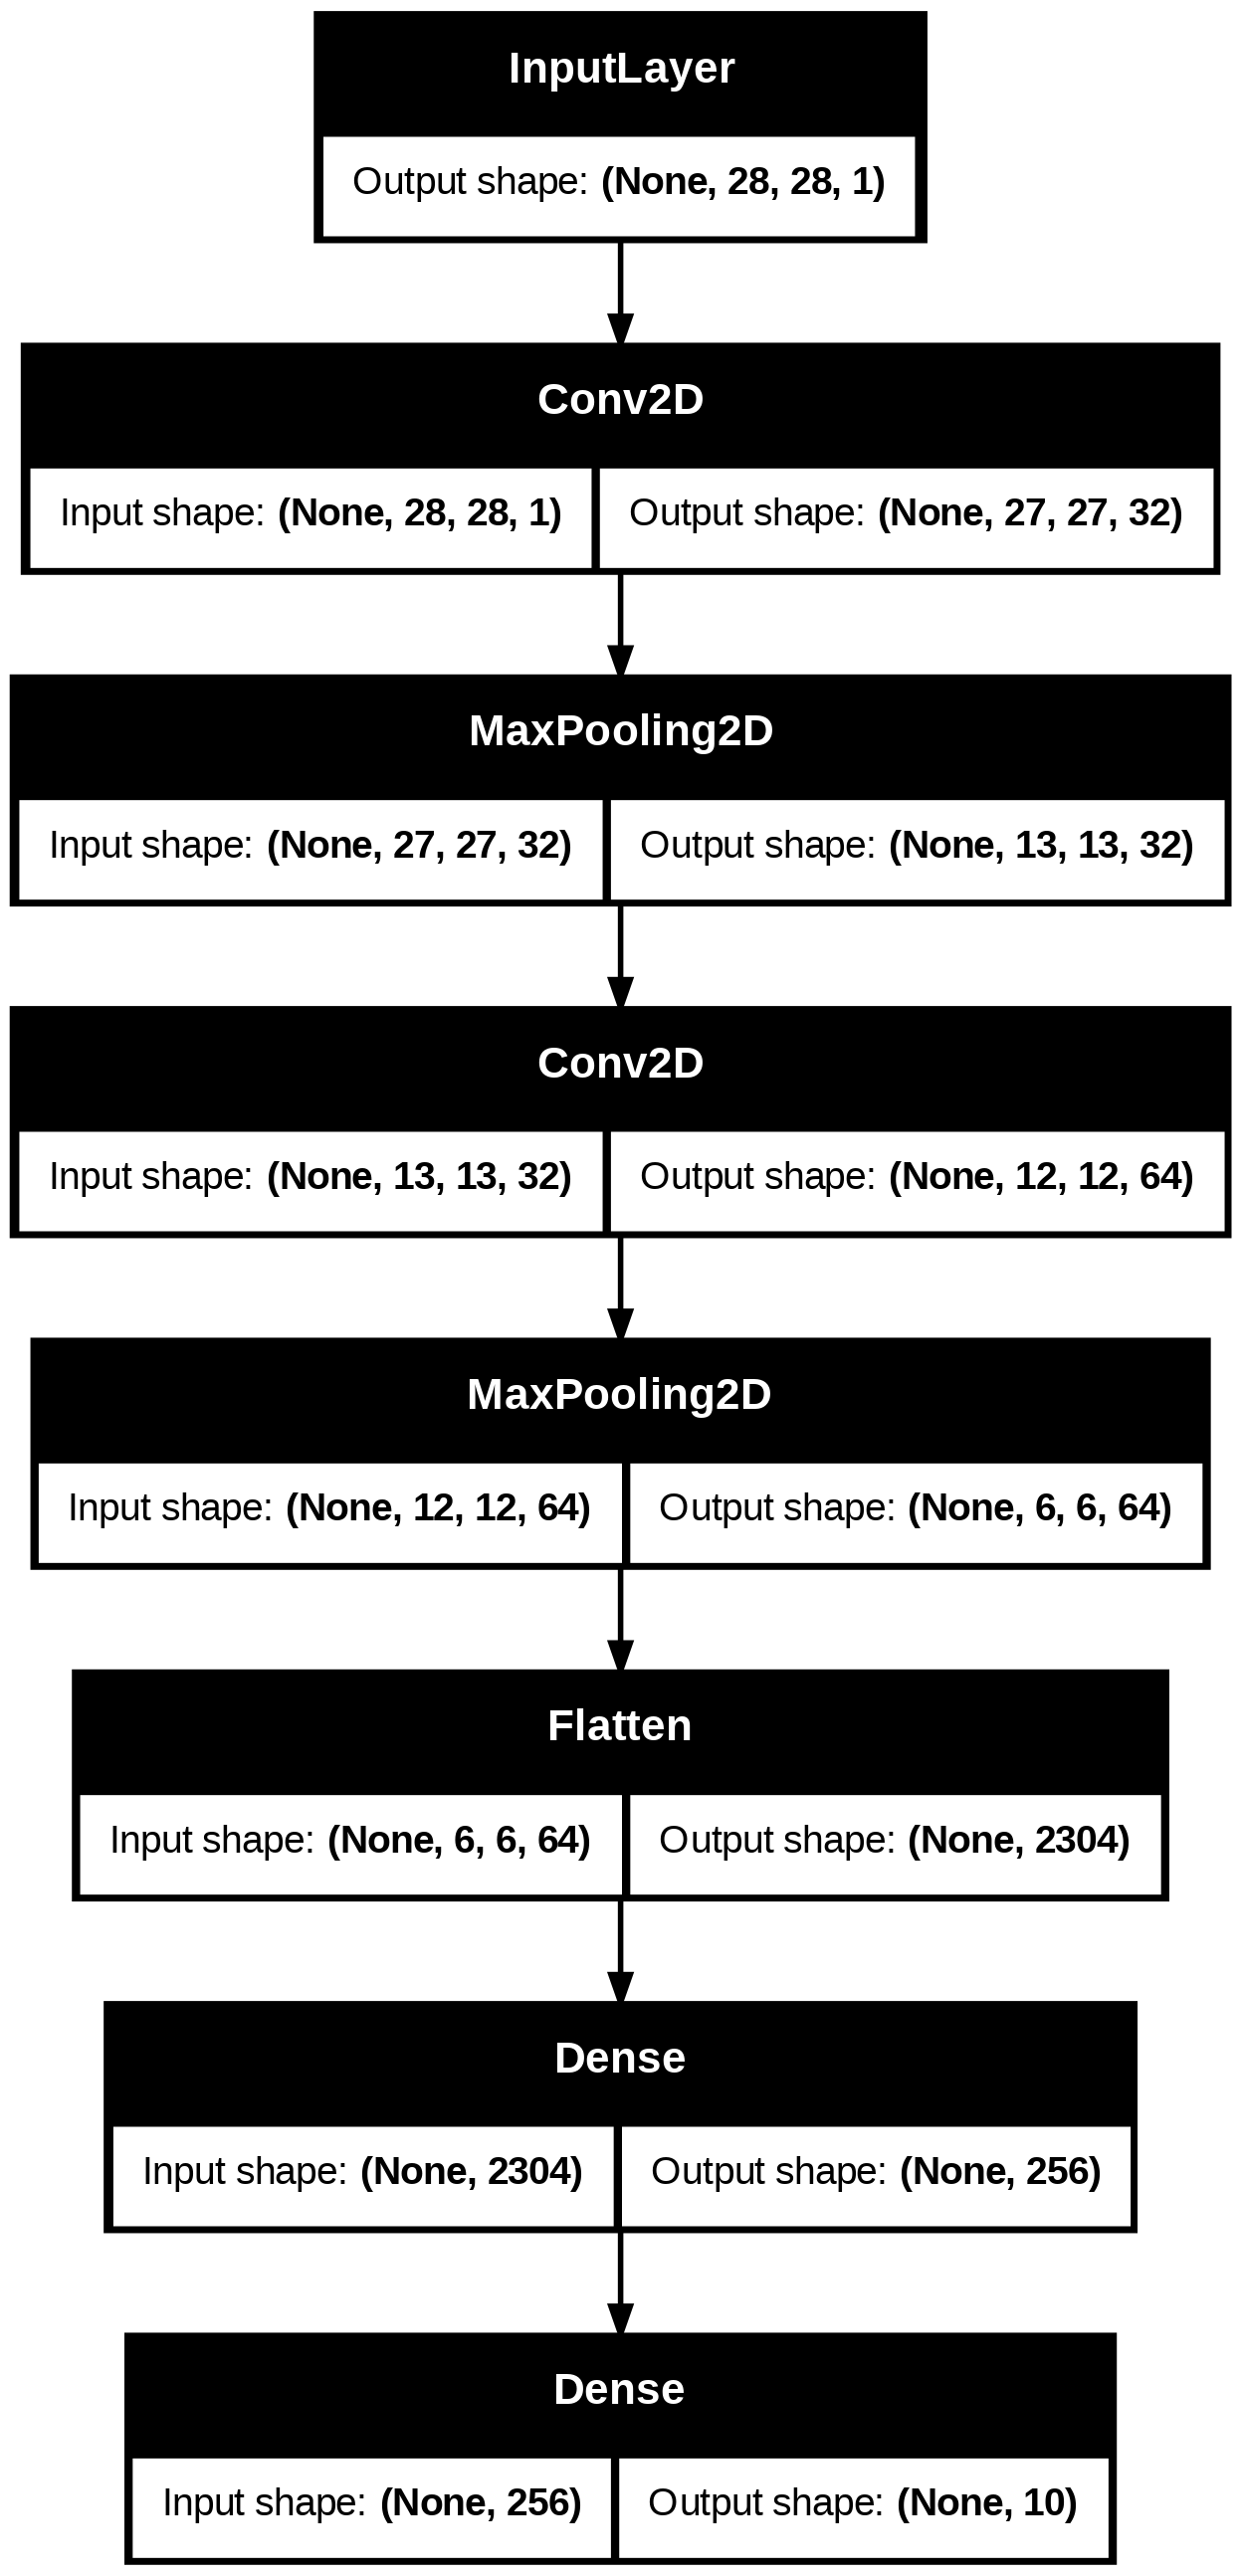

In [ ]:
keras.utils.plot_model(model ,show_shapes=True)

# Now we can use some optimizer like adam , SDG

In [ ]:
model.compile( loss = "sparse_categorical_crossentropy"
              ,optimizer="Adam" ,
              metrics = ['accuracy'])

Train model


In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size = 32,
    epochs = 6x,
    validation_split =0.2
)

Epoch 1/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8378 - loss: 0.4403 - val_accuracy: 0.8832 - val_loss: 0.3239
Epoch 2/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8916 - loss: 0.2950 - val_accuracy: 0.8982 - val_loss: 0.2797
Epoch 3/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9085 - loss: 0.2474 - val_accuracy: 0.9044 - val_loss: 0.2622
Epoch 4/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9229 - loss: 0.2115 - val_accuracy: 0.9064 - val_loss: 0.2560
Epoch 5/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9353 - loss: 0.1790 - val_accuracy: 0.9063 - val_loss: 0.2594
Epoch 6/6
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9463 - loss: 0.1480 - val_accuracy: 0.9060 - val_loss: 0.2773


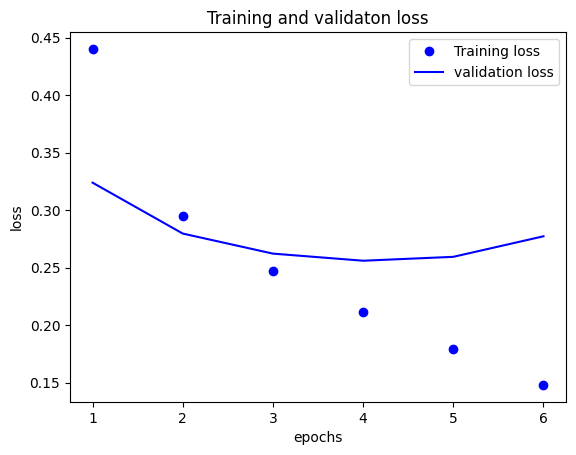

In [ ]:
plt_curve_loss(history)


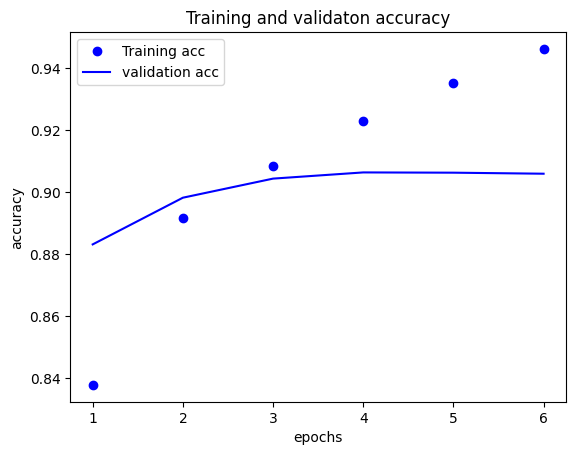

In [ ]:
plot_acc_curves(history)

In [ ]:
print("test accuracy : " , model.evaluate(x_test , y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9047 - loss: 0.2923
test accuracy :  [0.2922877073287964, 0.904699981212616]
